In [ ]:
! pip install tensorflow
pip install seaborn

In [51]:
# Libraries

import tensorflow as tf 

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

In [52]:
# load the datasets

train_df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/Deep Learning/Dataset/mnist_train.csv/mnist_train.csv")

test_df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/Deep Learning/Dataset/mnist_test.csv/mnist_test.csv")
train_df.head()
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [53]:
def preprocess(train_df, test_df):

    # split the data into features and labels

    X_train = train_df.drop("label", axis=1).values

    y_train = train_df["label"].values

    X_test = test_df.drop("label", axis=1).values

    y_test = test_df["label"].values

    

    # normalize the data

    X_train = X_train / 255.0

    X_test = X_test / 255.0

    
    # reshape data to 2D (28, 28) for the Flatten layer in the model
    X_train = X_train.reshape(-1, 28, 28)
    X_test = X_test.reshape(-1, 28, 28)
    

    return X_train, y_train, X_test, y_test

In [54]:
# model building

# version 1: single layer model



def build_model_v1():

    model = tf.keras.Sequential([

        tf.keras.layers.Flatten(input_shape=(28, 28)),

        tf.keras.layers.Dense(10, activation="softmax")

    ])

    

    model.compile(optimizer="adam",

                  loss="sparse_categorical_crossentropy",

                  metrics=["accuracy"])

    

    return model

In [55]:
# version 2: add hidden layer



def build_model_v2():

    model = tf.keras.Sequential([

        tf.keras.layers.Flatten(input_shape=(28, 28)),

        tf.keras.layers.Dense(128, activation="relu"),

        tf.keras.layers.Dense(10, activation="softmax")

    ])

    

    model.compile(optimizer="adam",

                  loss="sparse_categorical_crossentropy",

                  metrics=["accuracy"])

    

    return model

In [56]:
# version 3: deeper model



def build_model_v3():

    model = tf.keras.Sequential([

        tf.keras.layers.Flatten(input_shape=(28, 28)),

        tf.keras.layers.Dense(256, activation="relu"),

        tf.keras.layers.Dense(128, activation="relu"),

        tf.keras.layers.Dense(10, activation="softmax")

    ])

    

    model.compile(optimizer="adam",

                  loss="sparse_categorical_crossentropy",

                  metrics=["accuracy"])

    

    return model

In [57]:
# train pipeline



def train_model(model, x_train, y_train):

    history = model.fit(

        x_train, y_train, 

        epochs=10, 

        validation_split=0.2)

    return history

In [58]:
# evaluation pipeline



def evaluate_model(model, x_test, y_test):

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    print(f"Test accuracy: {test_acc:.4f}")

    

    preds = model.predict(x_test)

    preds_classes = np.argmax(preds, axis=1)

    

    # handle one-hot labels

    if len(y_test.shape) > 1:

        y_true = np.argmax(y_test, axis=1)

    else:

        y_true = y_test

        

    print(classification_report(y_true, preds_classes))

    

    return test_loss, test_acc

In [59]:
# visual representation of results



def plot_history(history, title="Model Performance"):

    plt.figure()

    plt.plot(history.history["accuracy"])

    plt.plot(history.history["val_accuracy"])

    plt.title(title)

    plt.ylabel("Accuracy")

    plt.xlabel("Epoch")

    plt.legend(["Train", "Validation"])

    plt.show()

In [60]:
# run full pipeline



MODEL_REGISTRY = {

    "Model_V1": build_model_v1,

    "Model_V2": build_model_v2,

    "Model_V3": build_model_v3

}



def run_pipeline(model_name, train_df, test_df):

    # preprocess the data

    X_train, y_train, X_test, y_test = preprocess(train_df, test_df)

    

    # build the model

    model_builder = MODEL_REGISTRY.get(model_name)

    if not model_builder:

        raise ValueError(f"Model {model_name} not found in registry.")

    

    model = model_builder()

    

    # train the model

    history = train_model(model, X_train, y_train)

    

    # evaluate the model

    test_loss, test_acc = evaluate_model(model, X_test, y_test)

    

    # plot the training history

    plot_history(history, title=f"{model_name} Performance")

    

    return model

In [61]:
# evaluation metrics



def evaluate_model(model, X_test, y_test):

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"Test Accuracy: {acc:.4f}")

    return {"loss": loss, "accuracy": acc}

In [62]:
# model performances



def summarize_results(results):

    print("\nModel Performance Summary\n")

    print("{:<12} {:<10} {:<10}".format("Model", "Accuracy", "Loss"))

    print("-" * 34)

    

    for name, res in results.items():

        acc = res["metrics"]["accuracy"]

        loss = res["metrics"]["loss"]

        print("{:<12} {:<10.4f} {:<10.4f}".format(name, acc, loss))

def plot_model_comparison(results):

    names = list(results.keys())

    accuracies = [results[n]["metrics"]["accuracy"] for n in names]

    

    plt.figure()

    plt.bar(names, accuracies)

    plt.title("Model Accuracy Comparison")

    plt.ylabel("Accuracy")

    plt.xlabel("Model")

    plt.show()

In [63]:
def select_best_model(results):

    best_name = max(results, key=lambda x: results[x]["metrics"]["accuracy"])

    print(f"\nBest Model: {best_name}")

    return results[best_name]["model"]

In [64]:
# run full workflow

def run_full_workflow(train_df, test_df):

    results = {}

    

    for model_name in MODEL_REGISTRY.keys():

        print(f"\nRunning pipeline for {model_name}...")

        model = run_pipeline(model_name, train_df, test_df)

        metrics = evaluate_model(model, *preprocess(train_df, test_df)[2:])

        results[model_name] = {"model": model, "metrics": metrics}

    

    summarize_results(results)

    plot_model_comparison(results)

    best_model = select_best_model(results)

    

    return best_model


Running pipeline for Model_V1...


c:\Users\Dell\miniconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8683 - loss: 0.5072 - val_accuracy: 0.9114 - val_loss: 0.3186
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9116 - loss: 0.3174 - val_accuracy: 0.9174 - val_loss: 0.2876
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9180 - loss: 0.2926 - val_accuracy: 0.9211 - val_loss: 0.2798
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9215 - loss: 0.2814 - val_accuracy: 0.9264 - val_loss: 0.2687
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9234 - loss: 0.2736 - val_accuracy: 0.9249 - val_loss: 0.2679
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9253 - loss: 0.2680 - val_accuracy: 0.9273 - val_loss: 0.2641
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9269 - loss: 0.2634 - val_accuracy: 0.9285 - val_loss: 0.2632
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9273 - loss: 0.2604

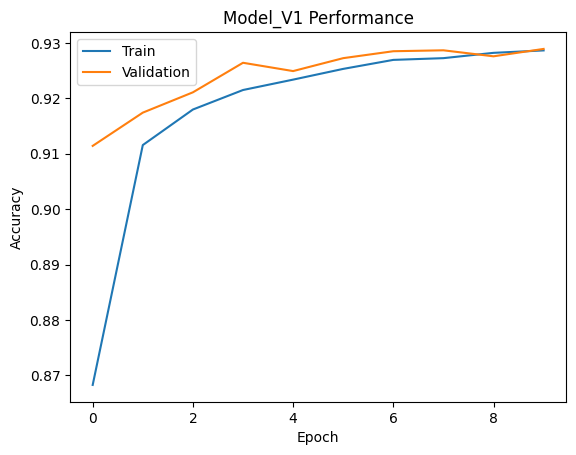

Test Accuracy: 0.9256

Running pipeline for Model_V2...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9182 - loss: 0.2877 - val_accuracy: 0.9549 - val_loss: 0.1576
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9624 - loss: 0.1277 - val_accuracy: 0.9656 - val_loss: 0.1180
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9735 - loss: 0.0865 - val_accuracy: 0.9704 - val_loss: 0.0987
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9806 - loss: 0.0639 - val_accuracy: 0.9704 - val_loss: 0.1000
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9852 - loss: 0.0484 - val_accuracy: 0.9748 - val_loss: 0.0882
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9887 - loss: 0.0366 - val_accuracy: 0.9722 - val_loss: 0.0941
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9910 - loss: 0.0299 - val_accuracy: 0.9721 - val_loss: 0.0991
Epoch 8/10
1500/1500 ━━━━━━━

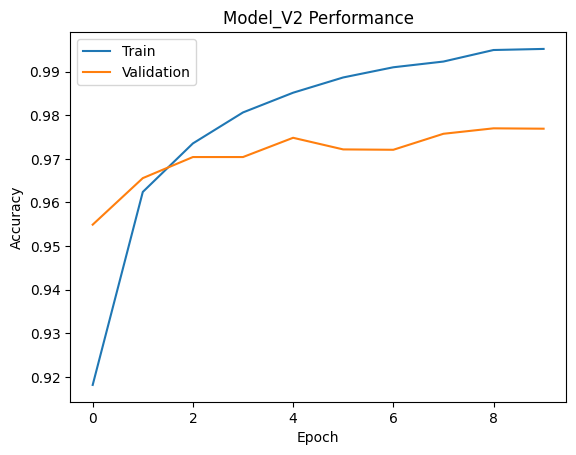

Test Accuracy: 0.9784

Running pipeline for Model_V3...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9312 - loss: 0.2318 - val_accuracy: 0.9666 - val_loss: 0.1154
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9707 - loss: 0.0947 - val_accuracy: 0.9670 - val_loss: 0.1058
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9798 - loss: 0.0639 - val_accuracy: 0.9735 - val_loss: 0.0902
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9850 - loss: 0.0464 - val_accuracy: 0.9723 - val_loss: 0.1038
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9886 - loss: 0.0359 - val_accuracy: 0.9750 - val_loss: 0.0967
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9906 - loss: 0.0284 - val_accuracy: 0.9700 - val_loss: 0.1190
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9919 - loss: 0.0237 - val_accuracy: 0.9740 - val_loss: 0.1155
Epoch 8/10
1500/1500 ━━━━━

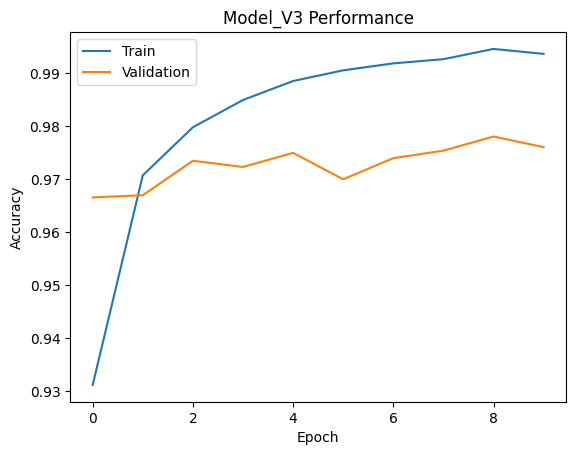

Test Accuracy: 0.9752

Model Performance Summary

Model        Accuracy   Loss      
----------------------------------
Model_V1     0.9256     0.2708    
Model_V2     0.9784     0.0764    
Model_V3     0.9752     0.1057    


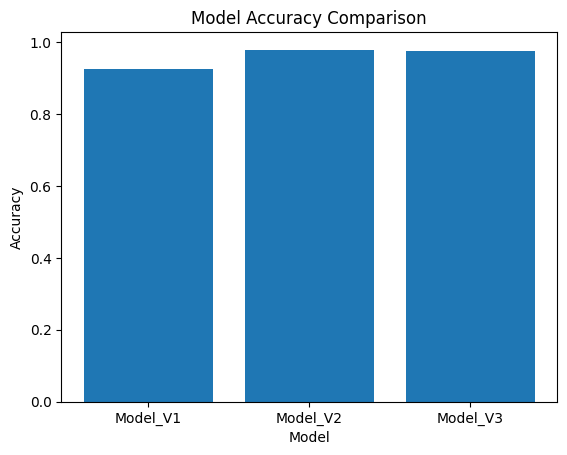


Best Model: Model_V2


In [65]:
# call the full workflow

best_model = run_full_workflow(train_df, test_df)